# Tester_branch에서 성능 확인 진행

In [3]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 학습데이터와 테스트 데이터로 분리 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

In [5]:
# Grid Search 를 활용한 하이퍼파라미터 튜닝
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Decision Tree 모델 생성 및 학습
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 학습
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("="*20, " DT 성능 확인 ", "="*20)
print("DT accuracy :", accuracy)
print(classification_report(y_test, y_pred))


====================  DT 성능 확인  ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [7]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("="*20, " XGB 성능 확인 ", "="*20)
print("XGB accuracy :", xgb_acc)
print(classification_report(y_test, y_pred_xgb))

====================  XGB 성능 확인  ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

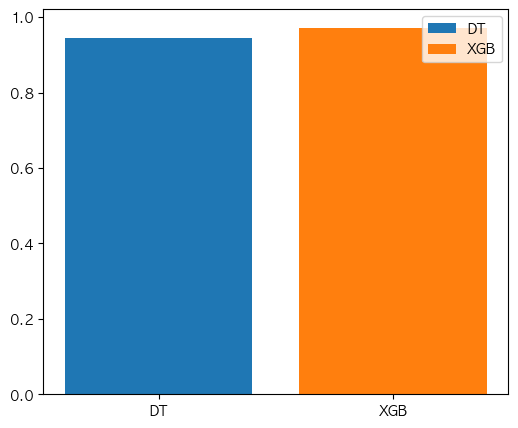

In [14]:

import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'


models = ['DT', 'XGB']
scores = [accuracy, xgb_acc]

plt.figure(figsize=(6, 5))
bars = plt.bar(models, scores, color=['#1f77b4', '#ff7f0e'])
plt.xticks(models)
plt.legend(bars, models)
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">